In [2]:
import yfinance as yf
import pandas_datareader.data as web
import pandas as pd
import numpy as np
import datetime

# Setup Parameters
start_date = "2010-01-01"
end_date = "2025-12-31"

# Collect Core Equity Variables (Yahoo Finance)
# S&P 500 (^GSPC) and Euro STOXX 50 (^STOXX50E)
equity_tickers = ["^GSPC", "^STOXX50E"]
equity_raw = yf.download(equity_tickers, start=start_date, end=end_date, interval="1mo", auto_adjust=False)
equity_data = equity_raw['Adj Close'].rename(columns={'^GSPC': 'SP500', '^STOXX50E': 'EUROSTOXX50'})

# Collect Inflation Benchmarks (FRED)
# US CPI (CPIAUCSL) and Euro Area HICP (CP0000EZ19M086NEST)
inflation_tickers = ['CPIAUCSL', 'CP0000EZ19M086NEST']
inflation_data = web.DataReader(inflation_tickers, 'fred', start_date, end_date)
inflation_data.columns = ['US_CPI', 'EA_HICP']

# Merge and Align Data (Directly aligned to Month Start)
# This ensures all data series have the same monthly frequency
df = pd.concat([equity_data, inflation_data], axis=1).resample('MS').first().dropna()

# Data Transformations
# Log-levels are used to examine stochastic properties
log_df = np.log(df)

# First difference of logs (Returns and Inflation Rates) for modeling
returns_df = log_df.diff().dropna()
returns_df.columns = ['SP500', 'EUROSTOXX', 'CPI', 'HICP']
# Final Output Check
print('Dataset Complete')
print(returns_df.head())

[*********************100%***********************]  2 of 2 completed


Dataset Complete
               SP500  EUROSTOXX       CPI      HICP
2010-02-01  0.028115  -0.017569 -0.000952  0.003162
2010-03-01  0.057133   0.071657  0.000331  0.010936
2010-04-01  0.014651  -0.039775  0.000230  0.004084
2010-05-01 -0.085532  -0.076173 -0.000520  0.001179
2010-06-01 -0.055388  -0.014253 -0.000419  0.000000


In [3]:
# Examine the stochastic properties of variables through stationarity
from statsmodels.tsa.stattools import adfuller

def run_adf_test(series, name):
 # 'autolag' set to 'AIC'
    result = adfuller(series.dropna(), autolag='AIC')

    print(f'--- ADF Test: {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')

   # Decision rule: p-value < 0.05 rejects the null hypothesis of a unit root
    if result[1] < 0.05:
        print('Result: Stationary (I(0))')
    else:
        print('Result: Non-Stationary (Contains Unit Root, I(1))')
    print('-' * 30)

# Test Log-Levels for all 4 variables (log_df)
for col in log_df.columns:
    run_adf_test(log_df[col], col)

# Test Returns/Inflation for all 4 variables (returns_df)
for col in returns_df.columns:
    run_adf_test(returns_df[col], col)

--- ADF Test: SP500 ---
ADF Statistic: 0.1498
p-value: 0.9693
Result: Non-Stationary (Contains Unit Root, I(1))
------------------------------
--- ADF Test: EUROSTOXX50 ---
ADF Statistic: -0.6562
p-value: 0.8578
Result: Non-Stationary (Contains Unit Root, I(1))
------------------------------
--- ADF Test: US_CPI ---
ADF Statistic: 0.4735
p-value: 0.9840
Result: Non-Stationary (Contains Unit Root, I(1))
------------------------------
--- ADF Test: EA_HICP ---
ADF Statistic: 0.1689
p-value: 0.9705
Result: Non-Stationary (Contains Unit Root, I(1))
------------------------------
--- ADF Test: SP500 ---
ADF Statistic: -11.5707
p-value: 0.0000
Result: Stationary (I(0))
------------------------------
--- ADF Test: EUROSTOXX ---
ADF Statistic: -14.2015
p-value: 0.0000
Result: Stationary (I(0))
------------------------------
--- ADF Test: CPI ---
ADF Statistic: -2.2599
p-value: 0.1852
Result: Non-Stationary (Contains Unit Root, I(1))
------------------------------
--- ADF Test: HICP ---
ADF Sta

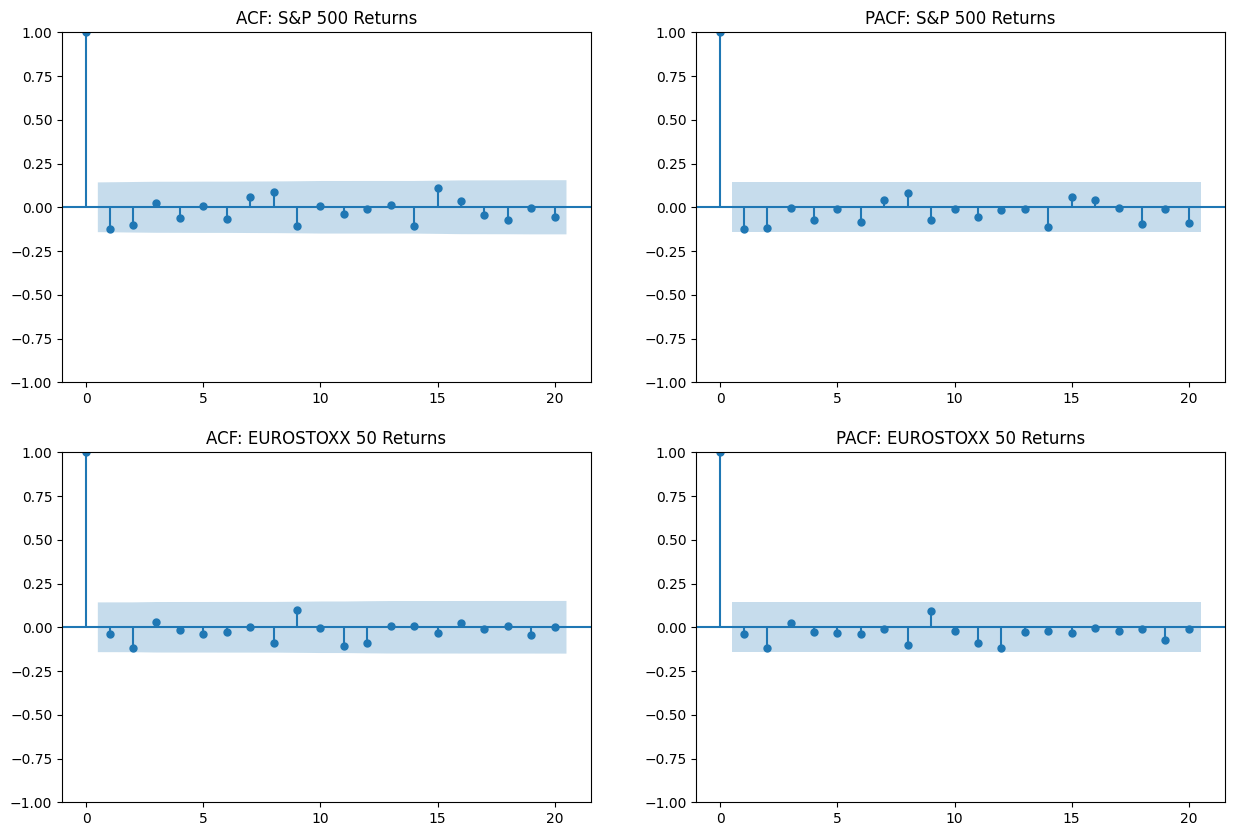

In [4]:
# Identification (ACF & PACF plots)
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Identification for S&P 500 & EUROSTOXX
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ACF helps identify the Moving Average (MA) order 'q'
plot_acf(returns_df['SP500'], ax=axes[0, 0], lags=20, title='ACF: S&P 500 Returns')
plot_pacf(returns_df['SP500'], ax=axes[0, 1], lags=20, title='PACF: S&P 500 Returns')

# PACF helps identify the Autoregressive (AR) order 'p'
plot_acf(returns_df['EUROSTOXX'], ax=axes[1, 0], lags=20, title='ACF: EUROSTOXX 50 Returns')
plot_pacf(returns_df['EUROSTOXX'], ax=axes[1, 1], lags=20, title='PACF: EUROSTOXX 50 Returns')

plt.show()


In [5]:
from statsmodels.tsa.arima.model import ARIMA

# Split the data into 80% training and 20% testing
train_size = int(len(returns_df) * 0.8)
train, test = returns_df['SP500'][0:train_size], returns_df['SP500'][train_size:len(returns_df)]

# Estimate the model (using ARIMA(1,0,1) as identified in identification plots
# Note: d=0 because returns_df is already stationary
model = ARIMA(train, order=(1, 0, 1))
results = model.fit()

# The summary table contains the AIC
print(results.summary())

# Can also access the AIC value directly to compare different orders
print(f'AIC for this model: {results.aic}')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  SP500   No. Observations:                  152
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 266.871
Date:                Thu, 23 Apr 2026   AIC                           -525.743
Time:                        15:23:52   BIC                           -513.647
Sample:                    02-01-2010   HQIC                          -520.829
                         - 09-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0081      0.003      2.513      0.012       0.002       0.014
ar.L1          0.4167      0.375      1.111      0.267      -0.319       1.152
ma.L1         -0.5596      0.347     -1.613      0.1

Test RMSE: 0.03686


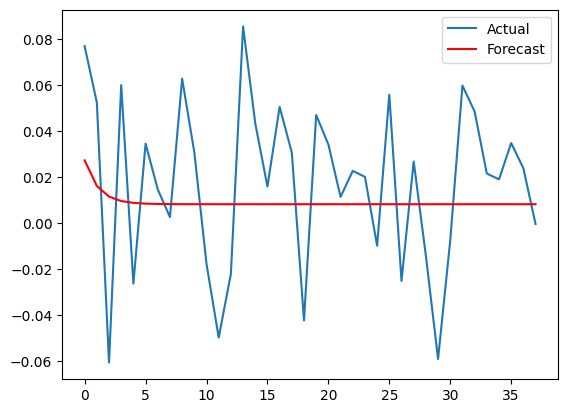

In [6]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# Generate forecast for the length of the test set
forecast = results.forecast(steps=len(test))

# Calculate RMSE to justify model performance
mse = mean_squared_error(test, forecast)
rmse = sqrt(mse)
print(f'Test RMSE: {rmse:.5f}')

# Plotting the results
plt.plot(test.values, label='Actual')
plt.plot(forecast.values, color='red', label='Forecast')
plt.legend()
plt.show()

In [7]:
# Transform inflation to be stationary (second-difference of logs)
# This represents the monthly change in the inflation rate
returns_df['D_CPI'] = returns_df['CPI'].diff()
returns_df['D_HICP'] = returns_df['HICP'].diff()

# Re-verify stationarity with the ADF test
print('--- ADF Test: Second-Difference CPI ---')
# autolag='AIC' follows the seminar approach for lag selection
res_cpi = adfuller(returns_df['D_CPI'].dropna(), autolag='AIC')
print(f"p-value: {res_cpi[1]:.4f}")

print('\n--- ADF Test: Second-Difference HICP ---')
res_hicp = adfuller(returns_df['D_HICP'].dropna(), autolag='AIC')
print(f'p-value: {res_hicp[1]:.4f}')

# Drop the new NaNs to maintain a clean dataset for the VAR
returns_df = returns_df.dropna()

--- ADF Test: Second-Difference CPI ---
p-value: 0.0000

--- ADF Test: Second-Difference HICP ---
p-value: 0.0028


In [8]:
# Fit the model for Euro STOXX 50 returns
train_stoxx = returns_df['EUROSTOXX'][:train_size]
test_stoxx = returns_df['EUROSTOXX'][train_size:]

# Estimate the model (using ARIMA(1,0,1) as identified in identification plots)
model_stoxx = ARIMA(train_stoxx, order=(1, 0, 1))
results_stoxx = model_stoxx.fit()

# Evaluate forecasting performance (RMSE)
forecast_stoxx = results_stoxx.forecast(steps=len(test_stoxx))
rmse_stoxx = np.sqrt(mean_squared_error(test_stoxx, forecast_stoxx))

print(f'Euro STOXX 50 Out-of-sample RMSE: {rmse_stoxx:.5f}')
# The results.summary() includes the Ljung-Box test for residuals
print(results_stoxx.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Euro STOXX 50 Out-of-sample RMSE: 0.03674
                               SARIMAX Results                                
Dep. Variable:              EUROSTOXX   No. Observations:                  152
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 245.704
Date:                Thu, 23 Apr 2026   AIC                           -483.408
Time:                        15:23:53   BIC                           -471.313
Sample:                    03-01-2010   HQIC                          -478.495
                         - 10-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0025      0.001      3.777      0.000       0.001       0.004
ar.L1          0.8718      0.074     11.803      0.000       0.727       1.017
ma.L1     

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Test RMSE: 0.03674


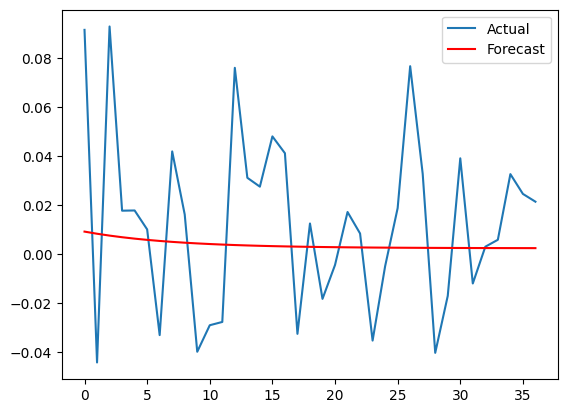

In [10]:
from sklearn.metrics import mean_squared_error
from math import sqrt

# Generate forecast for the length of the test set
forecast_stoxx = results_stoxx.forecast(steps=len(test_stoxx))

# Calculate RMSE to justify model performance
mse_stoxx = mean_squared_error(test_stoxx, forecast_stoxx)
rmse_stoxx = sqrt(mse_stoxx)
print(f'Test RMSE: {rmse_stoxx:.5f}')

# Plotting the results
plt.plot(test_stoxx.values, label='Actual')
plt.plot(forecast_stoxx.values, color='red', label='Forecast')
plt.legend()
plt.show()